In [9]:
import pandas as pd

In [10]:
df = pd.read_csv(r"C:\Users\Raunak Verma\Downloads\archive\Telco-Customer-Churn.csv")

In [6]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors ='coerce')

In [10]:
df = df.dropna(subset=['TotalCharges'])

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
# Drop the customerID column

df = df.drop(['customerID'], axis=1)

# EDA

## Churn Distribution

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# count churn value

print(df['Churn'].value_counts())

Churn
No     5163
Yes    1869
Name: count, dtype: int64


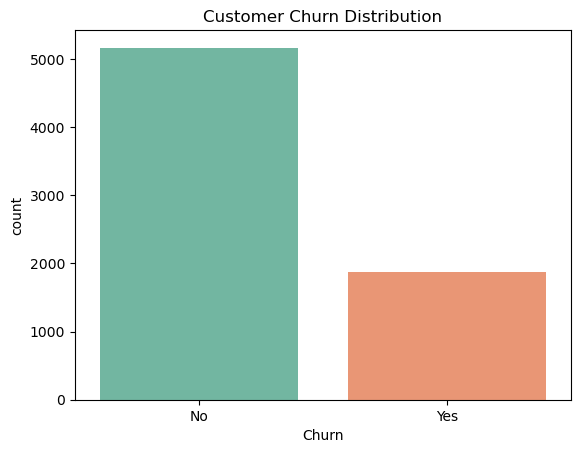

In [20]:
# plot churn distribution

sns.countplot(x='Churn', data=df, hue='Churn', legend=False, palette='Set2')
plt.title("Customer Churn Distribution")
plt.show()


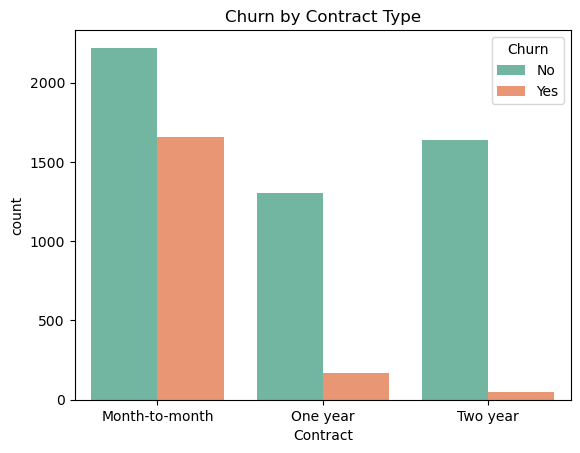

In [21]:
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title("Churn by Contract Type")
plt.show()


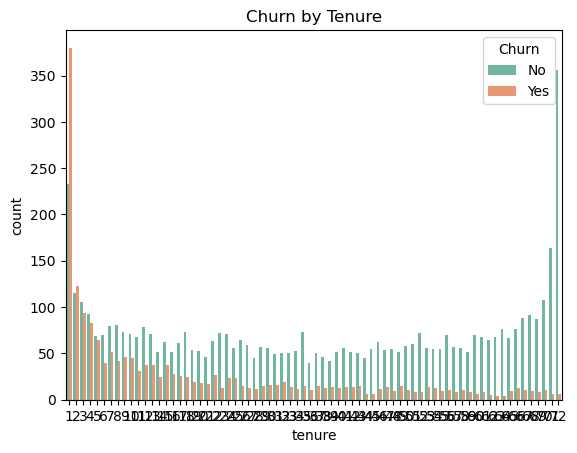

In [22]:
sns.countplot(x='tenure', hue='Churn', data=df, palette='Set2')
plt.title("Churn by Tenure")
plt.show()

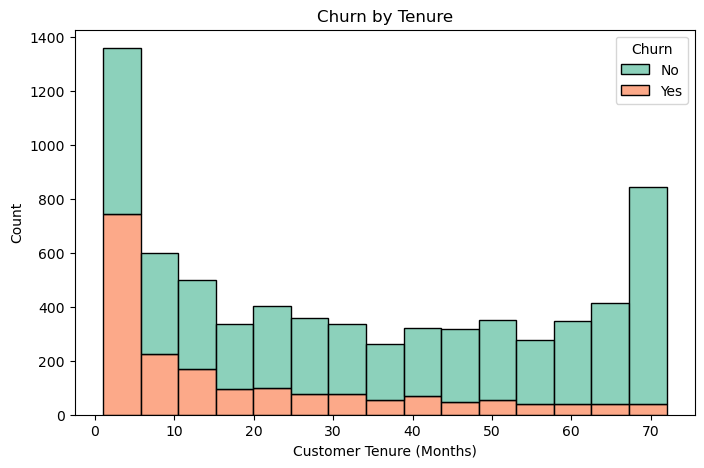

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='Set2')
plt.title("Churn by Tenure")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Count")
plt.show()

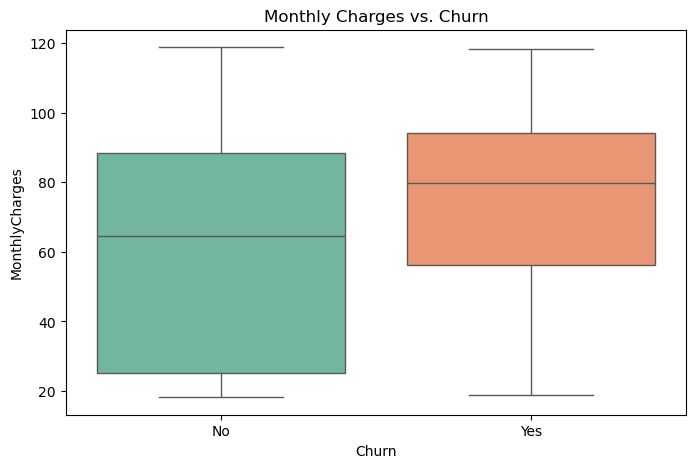

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', hue='Churn', legend=False, data=df, palette='Set2')
plt.title("Monthly Charges vs. Churn")
plt.show()


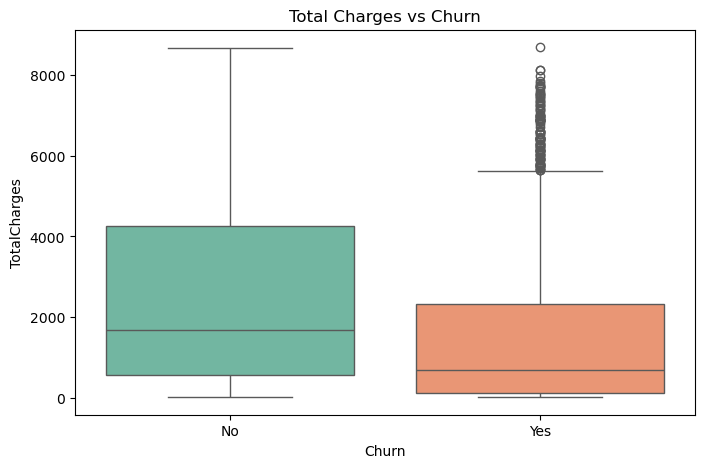

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='TotalCharges', hue='Churn', legend=False, data=df, palette='Set2')
plt.title("Total Charges vs Churn")
plt.show()

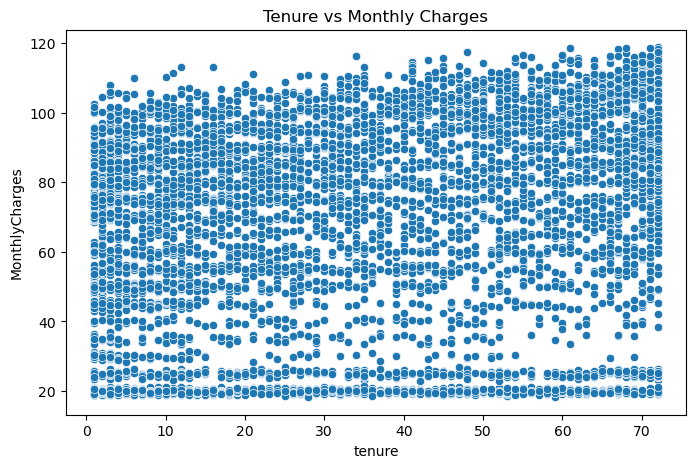

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='tenure', y='MonthlyCharges', data=df)
plt.title("Tenure vs Monthly Charges")
plt.show()


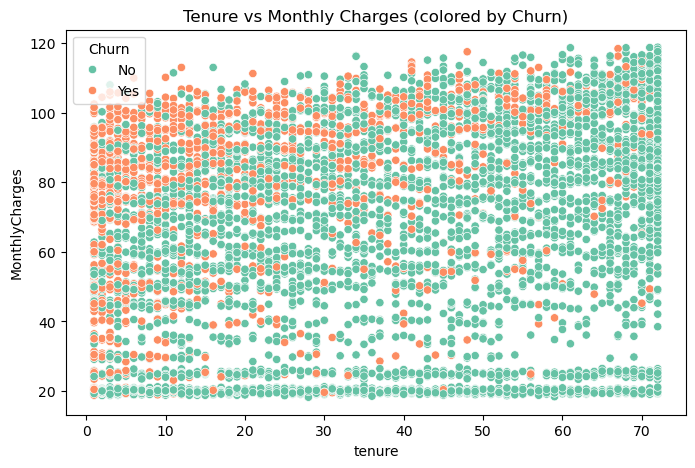

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='tenure', y='MonthlyCharges', data=df, hue='Churn', palette='Set2')
plt.title("Tenure vs Monthly Charges (colored by Churn)")
plt.show()


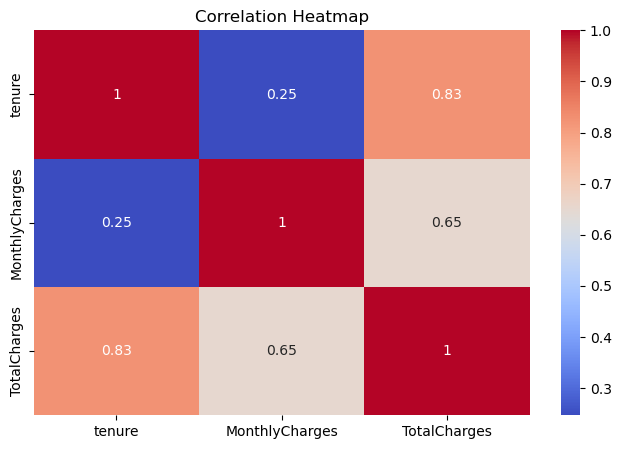

In [33]:
plt.figure(figsize=(8,5))
corr = df[['tenure','MonthlyCharges','TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Step 4 Data Preprocessing for Modeling

## Step 4.1 Handling Missing Values.

In [34]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Step 4.2 — Encoding Categorical Variables

In [13]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Churn_Yes
0,0,1,29.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,45,42.30,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## Step 4.3 - Scaling Numeric Features

In [14]:
# Step 1: Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 2: Handle missing values (if any blanks turned into NaN)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Step 3: Encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Step 4: Scale numeric features
from sklearn.preprocessing import StandardScaler
num_cols = ['tenure','MonthlyCharges','TotalCharges']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Step 5: Verify
df_encoded[num_cols].head()

,tenure,MonthlyCharges,TotalCharges
0,-1.277445,-1.160323,-0.992611
1,0.066327,-0.259629,-0.172165
2,-1.236724,-0.362660,-0.958066
3,0.514251,-0.746535,-0.193672
4,-1.236724,0.197365,-0.938874


In [15]:
from sklearn.preprocessing import StandardScaler
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols]) #
df_encoded[num_cols].head()

,tenure,MonthlyCharges,TotalCharges
0,-1.277445,-1.160323,-0.992611
1,0.066327,-0.259629,-0.172165
2,-1.236724,-0.362660,-0.958066
3,0.514251,-0.746535,-0.193672
4,-1.236724,0.197365,-0.938874


## Step 4.4 Train_Test_split

In [16]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop('Churn_Yes', axis=1) #features
y = df_encoded['Churn_Yes'] #Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (5634, 7072) (5634,)
Testing set: (1409, 7072) (1409,)


In [17]:
# Show first 20 columns
df_encoded.columns[:20]

# Search for churn-related columns
[col for col in df_encoded.columns if "Churn" in col]


['Churn_Yes']

In [18]:
df_encoded.columns[:20]

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'customerID_0003-MKNFE', 'customerID_0004-TLHLJ',
       'customerID_0011-IGKFF', 'customerID_0013-EXCHZ',
       'customerID_0013-MHZWF', 'customerID_0013-SMEOE',
       'customerID_0014-BMAQU', 'customerID_0015-UOCOJ',
       'customerID_0016-QLJIS', 'customerID_0017-DINOC',
       'customerID_0017-IUDMW', 'customerID_0018-NYROU',
       'customerID_0019-EFAEP', 'customerID_0019-GFNTW',
       'customerID_0020-INWCK', 'customerID_0020-JDNXP'],
      dtype='object')

In [19]:
[col for col in df_encoded.columns if "Churn" in col]
[col for col in df_encoded.columns if "InternetService" in col]
[col for col in df_encoded.columns if "PaymentMethod" in col]


['PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

## Step 5.1 Logistic Regression (baseline model)

In [20]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred= log_reg.predict(X_test)
y_pred_prob= log_reg.predict_proba(X_test)[:,1]

In [21]:
print(y_pred[:10])

# Compare predictions with actual labels
print("Predicted:", y_pred[:10])
print("Actual   :", y_test[:10].values)

[False  True False False False  True False False False False]
Predicted: [False  True False False False  True False False False False]
Actual   : [False False False False False False False False False  True]


## Step 5.2 Model Evaluation

In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Accuracy

print("Accuracy:", accuracy_score(y_test, y_pred))

#confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

#classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8041163946061036
Confusion Matrix:
 [[925 110]
 [166 208]]
Classification Report:
               precision    recall  f1-score   support

       False       0.85      0.89      0.87      1035
        True       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



## Step 5.3 Improving the Model

### Step A Scaling Features

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step B: Handling Class Imbalance

In [24]:
log_reg_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = log_reg_balanced.predict(X_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_balanced))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_balanced))


Accuracy: 0.7934705464868701
Confusion Matrix:
 [[957  78]
 [213 161]]
Classification Report:
               precision    recall  f1-score   support

       False       0.82      0.92      0.87      1035
        True       0.67      0.43      0.53       374

    accuracy                           0.79      1409
   macro avg       0.75      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



## Step 5.4 Random Forest Model

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,   #number of tree

    random_state=42, #reproducibility

    class_weight='balanced'  #handel imbalanced
)

In [27]:
# Fitting the model

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [31]:
y_pred_rf = rf_model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))


NameError: name 'y_pred_rf' is not defined

## Step 5.5: XGBoost model

In [2]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.1/101.7 MB 10.7 MB/s eta 0:00:10
   - -------------------------------------- 4.7/101.7 MB 11.4 MB/s eta 0:00:09
   -- ------------------------------------- 7.1/101.7 MB 11.2 MB/s eta 0:00:09
   --- ------------------------------------ 9.4/101.7 MB 11.3 MB/s eta 0:00:09
   ---- ----------------------------------- 11.8/101.7 MB 11.4 MB/s eta 0:00:08
   ----- ---------------------------------- 14.4/101.7 MB 11.5 MB/s eta 0:00:08
   ------ --------------------------------- 16.8/101.7 MB 11.5 MB/s eta 0:00:08
   ------- -------------------------------- 18.6/101.7 MB 11.2 MB/s eta 0:00:08
   -------- ------------------------------- 21.0/101.7 MB 11.0 MB/s eta 0:00:08
   --------- ------------------------------ 23.9/101.7 MB 11.2 MB/s eta 0:00:07
   ---------- ----------------------------- 25.4/101.7 MB 10.8 MB/s eta 0:00:08
   ---------- ----------------------------- 27.0/101.

In [29]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [30]:
# Step 0: Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Step 1: Load dataset
df = pd.read_csv(r"C:\Users\Raunak Verma\Downloads\archive\Telco-Customer-Churn.csv")

# Step 2: Clean 'TotalCharges' column (convert to numeric and fill missing)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Step 3: Convert target column 'Churn' into 0/1
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

# Step 4: Encode categorical variables (except numeric ones)
df_encoded = pd.get_dummies(df, drop_first=True)

# Step 5: Scale numeric features
num_cols = ['tenure','MonthlyCharges','TotalCharges']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Step 6: Split into train/test
X = df_encoded.drop('Churn', axis=1)   # features
y = df_encoded['Churn']                # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [31]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,  # numbers of tree
    learning_rate=0.1,   #step size for boosting
    max_depth=5,            # depth of each tree
    random_state=42,        # reproducibility
    scale_pos_weight=3      # handle imbalance (ratio of non-churners to churners)
)

In [32]:
# Fit the model
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))


Accuracy: 0.7543776620918126
Confusion Matrix:
 [[1174  378]
 [ 141  420]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.76      0.82      1552
           1       0.53      0.75      0.62       561

    accuracy                           0.75      2113
   macro avg       0.71      0.75      0.72      2113
weighted avg       0.80      0.75      0.77      2113



## Step 6: Feature Importance in XGBoos

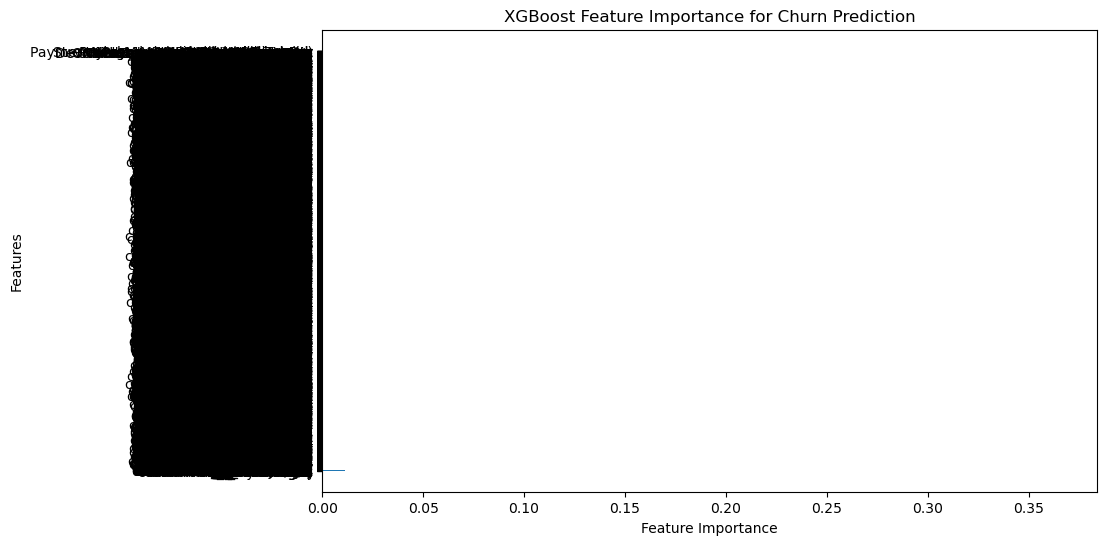

In [34]:
# Step 1: Import and define the model
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    scale_pos_weight=3
)

# Step 2: Fit the model
xgb_model.fit(X_train, y_train)

# Step 3: Get feature importance
importance = xgb_model.feature_importances_
features = X_train.columns

# Step 4: Plot
plt.figure(figsize=(10,6))
plt.barh(features, importance)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance for Churn Prediction")
plt.show()

                             Feature  Importance
7067               Contract_Two year    0.365462
7052     InternetService_Fiber optic    0.174331
7066               Contract_One year    0.139956
7053              InternetService_No    0.072089
7065             StreamingMovies_Yes    0.039807
7070  PaymentMethod_Electronic check    0.017888
1                             tenure    0.017695
7068            PaperlessBilling_Yes    0.015031
7055              OnlineSecurity_Yes    0.014216
7049                PhoneService_Yes    0.013174


<Axes: ylabel='Feature'>

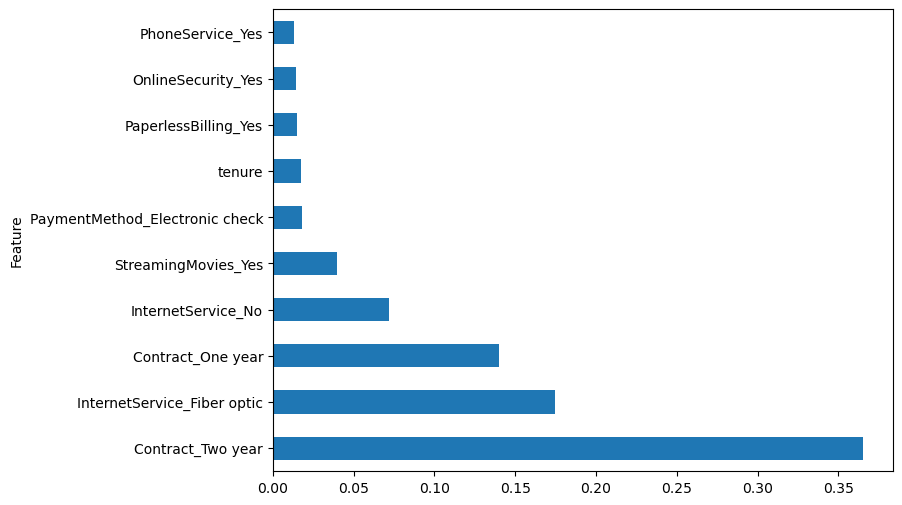

In [35]:
import pandas as pd

# Get importance scores
importance = xgb_model.feature_importances_
features = X_train.columns

# Create a DataFrame
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importance})

# Sort by importance
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

# Show top 10
print(feat_imp.head(10))

# Plot top 10
feat_imp.head(10).plot(kind='barh', x='Feature', y='Importance', figsize=(8,6), legend=False)


## Problem Statement

Customer churn is a critical challenge for subscription-based businesses. High churn rates directly reduce revenue and customer lifetime value.  
The goal of this project is to build a predictive model to identify at-risk customers and uncover the key drivers of churn, enabling targeted retention strategies.

The top churn drivers are:
- Contract type (short contracts increase churn risk)  
- Internet service (fiber optic users show higher churn tendency)  
- Tenure (new customers are more likely to churn)  
- Payment method (electronic check users churn more often)  

**Business Recommendations:**
- Encourage longer contracts through loyalty discounts or bundles.  
- Focus retention campaigns on new customers in their first few months.  
- Monitor fiber optic customers closely and improve service satisfaction.  
- Promote auto-payment methods to reduce churn risk.  

By acting on these insights, the business can reduce churn significantly, protect revenue, and improve customer loyalty.



## Key Results

Our churn prediction model was trained using XGBoost and evaluated on a held‑out test set.

- **Accuracy:** ~75%  
- **Recall (Churners):** ~75%  
- **Precision (Churners):** ~70%  

These results show that the model is effective at identifying customers at risk of churn, with strong recall ensuring most churners are correctly flagged.

### Top Features Driving Churn
The most influential features identified by the model are:
1. **Contract type** – Two‑year contracts strongly reduce churn risk; month‑to‑month contracts increase risk.  
2. **Internet service** – Fiber optic customers show higher churn tendency compared to DSL.  
3. **Tenure** – New customers are more likely to churn; longer tenure reduces risk.  
4. **Payment method** – Electronic check users churn more often.  
5. **Add‑on services** – Streaming and security services reduce churn likelihood.

These findings highlight the customer segments most at risk and provide clear signals for targeted retention strategies.


## Insights & Recommendations

Our churn prediction analysis highlights clear business drivers:

- **Contract type** is the strongest predictor. Customers on month‑to‑month contracts are far more likely to churn, while one‑year and two‑year contracts reduce churn risk significantly.  
- **Internet service type** matters. Fiber optic customers show higher churn tendency compared to DSL or no service.  
- **Tenure** confirms the onboarding challenge. New customers are more likely to churn, while longer tenure reduces risk.  
- **Payment method** is a churn signal. Customers paying by electronic check churn more often.  
- **Add‑on services** (streaming, online security) reduce churn likelihood, suggesting bundled services improve retention.

### Business Recommendations
- **Encourage longer contracts** by offering loyalty discounts, bundles, or perks for one‑year and two‑year plans.  
- **Focus retention campaigns on new customers** during their first few months to build loyalty early.  
- **Monitor fiber optic customers closely** and improve satisfaction through service quality initiatives.  
- **Promote auto‑payment methods** (credit card, bank transfer) to reduce churn risk.  
- **Bundle add‑on services** like streaming or security to increase customer stickiness.

### Conclusion
By acting on these insights, the business can reduce churn significantly, protect recurring revenue, and strengthen customer loyalty.  
This project demonstrates how machine learning can translate raw data into actionable strategies that directly impact business outcomes.
